# Freight Rate Prediction - Data Analysis

###  Objective: analyze the training and validation datasets, identify data-quality issues, engineer useful features, and decide how to prepare the data for a freight rate prediction model.

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Load data

train = pd.read_csv('../data/train_test.csv')
validation = pd.read_csv('../data/validation.csv')
template = pd.read_csv('../data/validation_predictions_template.csv')
december = pd.read_csv('../data/december_chart_inputs.csv')

In [6]:
# Check Shape And Columns of the DataFrames

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Template shape:", template.shape)
print("December shape:", december.shape)


Train shape: (48000, 14)
Validation shape: (12000, 13)
Template shape: (12000, 2)
December shape: (31, 7)


In [7]:
train.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [8]:
train.columns

Index(['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon',
       'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight',
       'date', 'market_index', 'quote_signal', 'posted_rate'],
      dtype='object')

In [9]:
# Target Variable Analysis

target = "posted_rate"

train[target].describe()

count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64

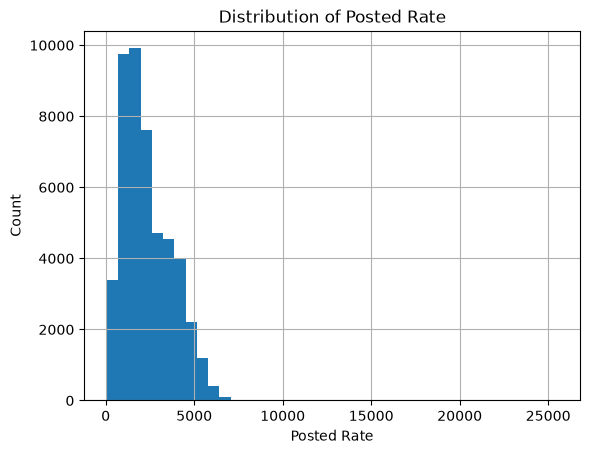

In [11]:
train["posted_rate"].hist(bins=40)
plt.title("Distribution of Posted Rate")
plt.xlabel("Posted Rate")
plt.ylabel("Count")
plt.show()

In [ ]:
# Missing Values Analysis

train.isna().sum()


load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          165
date              0
market_index    249
quote_signal      0
dtype: int64

In [14]:

validation.isna().sum()

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          165
date              0
market_index    249
quote_signal      0
dtype: int64

####   Missing values are present in `weight` and `market_index`. These will need to be handled before modeling.

In [15]:
# Duplicate Rows Analysis

train["load_id"].duplicated().sum()

np.int64(0)

In [16]:
validation["load_id"].duplicated().sum()

np.int64(0)

In [18]:
train.dtypes

load_id                 object
pickup                  object
delivery                object
pickup_lat             float64
pickup_lon             float64
delivery_lat           float64
delivery_lon           float64
distance               float64
equipment               object
weight                 float64
date            datetime64[ns]
market_index           float64
quote_signal           float64
posted_rate            float64
dtype: object

In [19]:
# date types

train['date'] = pd.to_datetime(train['date'])
validation['date'] = pd.to_datetime(validation['date']) 
december['date'] = pd.to_datetime(december['date'])

In [21]:
# Date Ranges

train["date"].min(), train["date"].max()

(Timestamp('2025-01-01 00:00:00'), Timestamp('2025-10-31 00:00:00'))

In [22]:

validation["date"].min(), validation["date"].max()

(Timestamp('2025-11-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

####  The training data covers January 2025 to October 2025, while the validation data covers November to December 2025.
#### Because the final predictions are future dates, a time-based validation split is more appropriate than a random split.

In [23]:
# Exploring numerical features

numeric_cols = [
      "pickup_lat", "pickup_lon",
      "delivery_lat", "delivery_lon",
      "distance", "weight",
      "market_index", "quote_signal",
      "posted_rate"
  ]

train[numeric_cols].describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


In [24]:
# Invalid values in the dataset
(train["weight"] <= 0).sum()

np.int64(292)

In [25]:
(validation["weight"] <= 0).sum()

np.int64(145)

####  Some weights are negative, which is not physically valid. Since the magnitude appears meaningful, I will convert negative weights to absolute values during preprocessing.

In [27]:
# Analyze Categorical Columns

categorical_cols = ["pickup", "delivery", "equipment"]

for col in categorical_cols:
      print(col)
      print("Train unique:", train[col].nunique())
      print("Validation unique:", validation[col].nunique())
      print()

pickup
Train unique: 64
Validation unique: 72

delivery
Train unique: 64
Validation unique: 72

equipment
Train unique: 3
Validation unique: 3



In [28]:
# Check Unseen Categories in Validation 

for col in ["pickup", "delivery"]:
      unseen = set(validation[col]) - set(train[col])
      print(col, sorted(unseen))

pickup ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']
delivery ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']


####  Some pickup and delivery cities appear in validation but not in training. The model preprocessing must handle unknown categories safely.

In [29]:
# Analyse Equipement column 

train["equipment"].value_counts()

train.groupby("equipment")["posted_rate"].agg(["count", "mean", "median"])

,count,mean,median
equipment,,,
Dry Van,27202,2271.548686,1953.035
Flatbed,8753,2445.087223,2076.810
Reefer,12045,2553.636939,2196.670


In [30]:
# Analyze Rate By Month

train["month"] = train["date"].dt.month

train.groupby("month")["posted_rate"].agg(["count", "mean", "median"])

,count,mean,median
month,,,
1,4918,2255.967048,1915.200
2,4337,2273.804801,1994.250
3,5036,2372.268092,2022.920
4,4819,2372.162308,2044.240
5,4913,2421.776342,2065.510
6,4783,2497.030115,2120.220
7,4912,2415.162030,2059.145
8,4759,2338.407661,2015.730
9,4670,2406.374013,2057.130


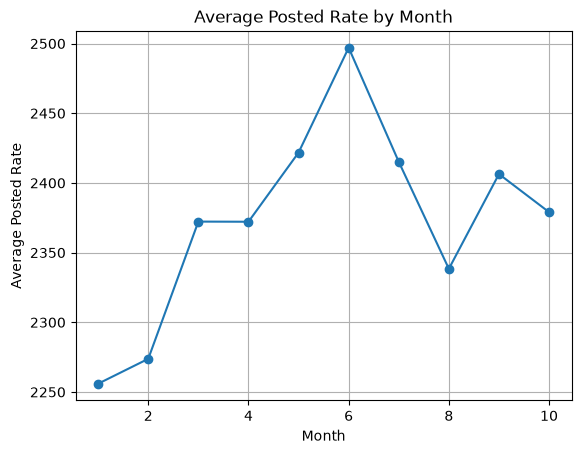

In [31]:
monthly_rate = train.groupby("month")["posted_rate"].mean()

monthly_rate.plot(marker="o")
plt.title("Average Posted Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Posted Rate")
plt.grid(True)
plt.show()

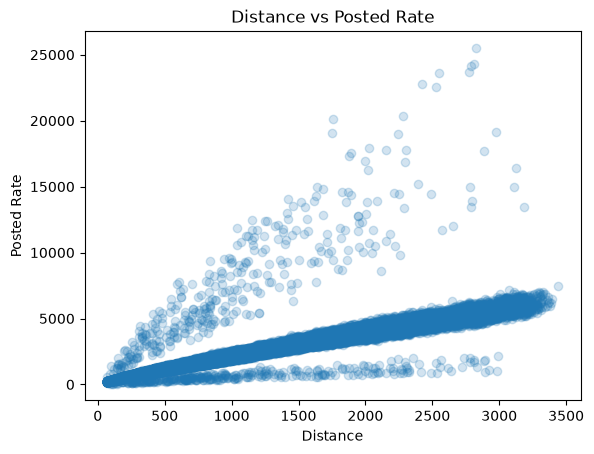

In [32]:
# Analyse Distance vs Posted Rate

plt.scatter(train["distance"], train["posted_rate"], alpha=0.2)
plt.title("Distance vs Posted Rate")
plt.xlabel("Distance")
plt.ylabel("Posted Rate")
plt.show()

In [33]:
train["rate_per_mile"] = train["posted_rate"] / train["distance"]
train["rate_per_mile"].describe()

count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
25%          1.986974
50%          2.145348
75%          2.342696
max         14.125294
Name: rate_per_mile, dtype: float64

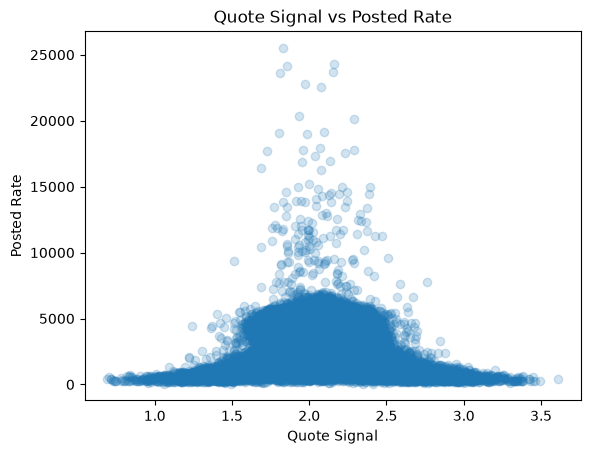

In [35]:
# Analyze Quote Signal and Market Index

train[["market_index", "quote_signal", "posted_rate"]].corr()

plt.scatter(train["quote_signal"], train["posted_rate"], alpha=0.2)
plt.title("Quote Signal vs Posted Rate")
plt.xlabel("Quote Signal")
plt.ylabel("Posted Rate")
plt.show()

### Feature engineering 


  Planned features:
  - Numeric: distance, weight, market_index, quote_signal, latitude/longitude columns
  - Categorical: pickup, delivery, equipment
  - Date features: month, day, day_of_week
  - Route feature: pickup + delivery lane
  - Optional: rate_per_mile only for analysis, not as model input because it uses the target

### Cleaning Strategy

  Cleaning decisions:
  - Convert date columns to datetime.
  - Convert negative weights to absolute values.
  - Impute missing weight values using the median weight.
  - Impute missing market_index values using the median market_index.
  - Use encoders that can handle unseen categories in validation.

###  Validation Strategy


 Validation strategy:
  Since the final prediction period is November-December 2025 and the training data ends in October 2025, I will use a time-based split:
  - Training split: January-August 2025
  - Holdout validation split: September-October 2025

  This better simulates predicting future freight rates.

###  Final EDA Conclusion

Conclusion:
  The dataset is suitable for a supervised regression model. `posted_rate` is the target variable. Important predictors include distance, equipment type, pickup/delivery locations, date, market_index, quote_signal, and weight. 
  The main data-quality issues are missing values and negative weights. The final model should use preprocessing that handles missing numeric values and unseen categorical values.